# Requirements

In [1]:
# !pip install -r ml_santi/requirements.txt

# LIBRARIES: 


In [3]:
# LIBRARIES: 


# !pip install -r ml_santi/requirements.txt
from dm_santi.data_wranggling import *

# CONFIGURATIONS: 


data_path = 'data/'

# LOAD DATA:

In [4]:
train = load_data_2df(data_path+"train.csv")
test = load_data_2df(data_path+"test.csv")

# EDA:

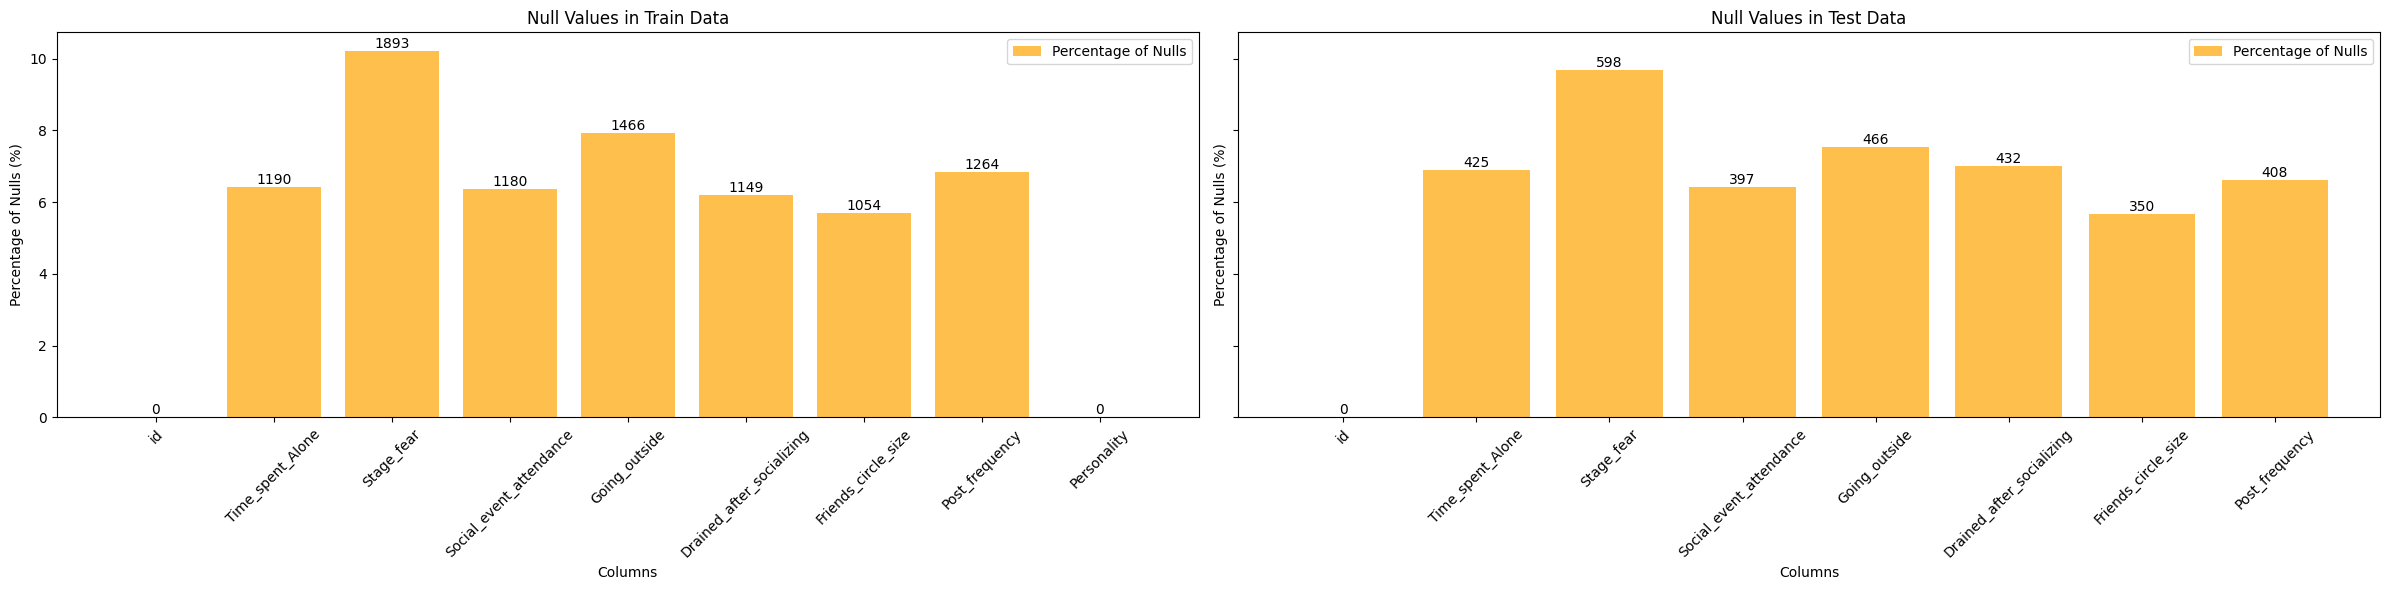

In [5]:
from dv_santi.null_viz import plot_nulls, investigate_null_imputation, investigate_null_deletion


plot_nulls(train, test, labels=('Train Data', 'Test Data'))

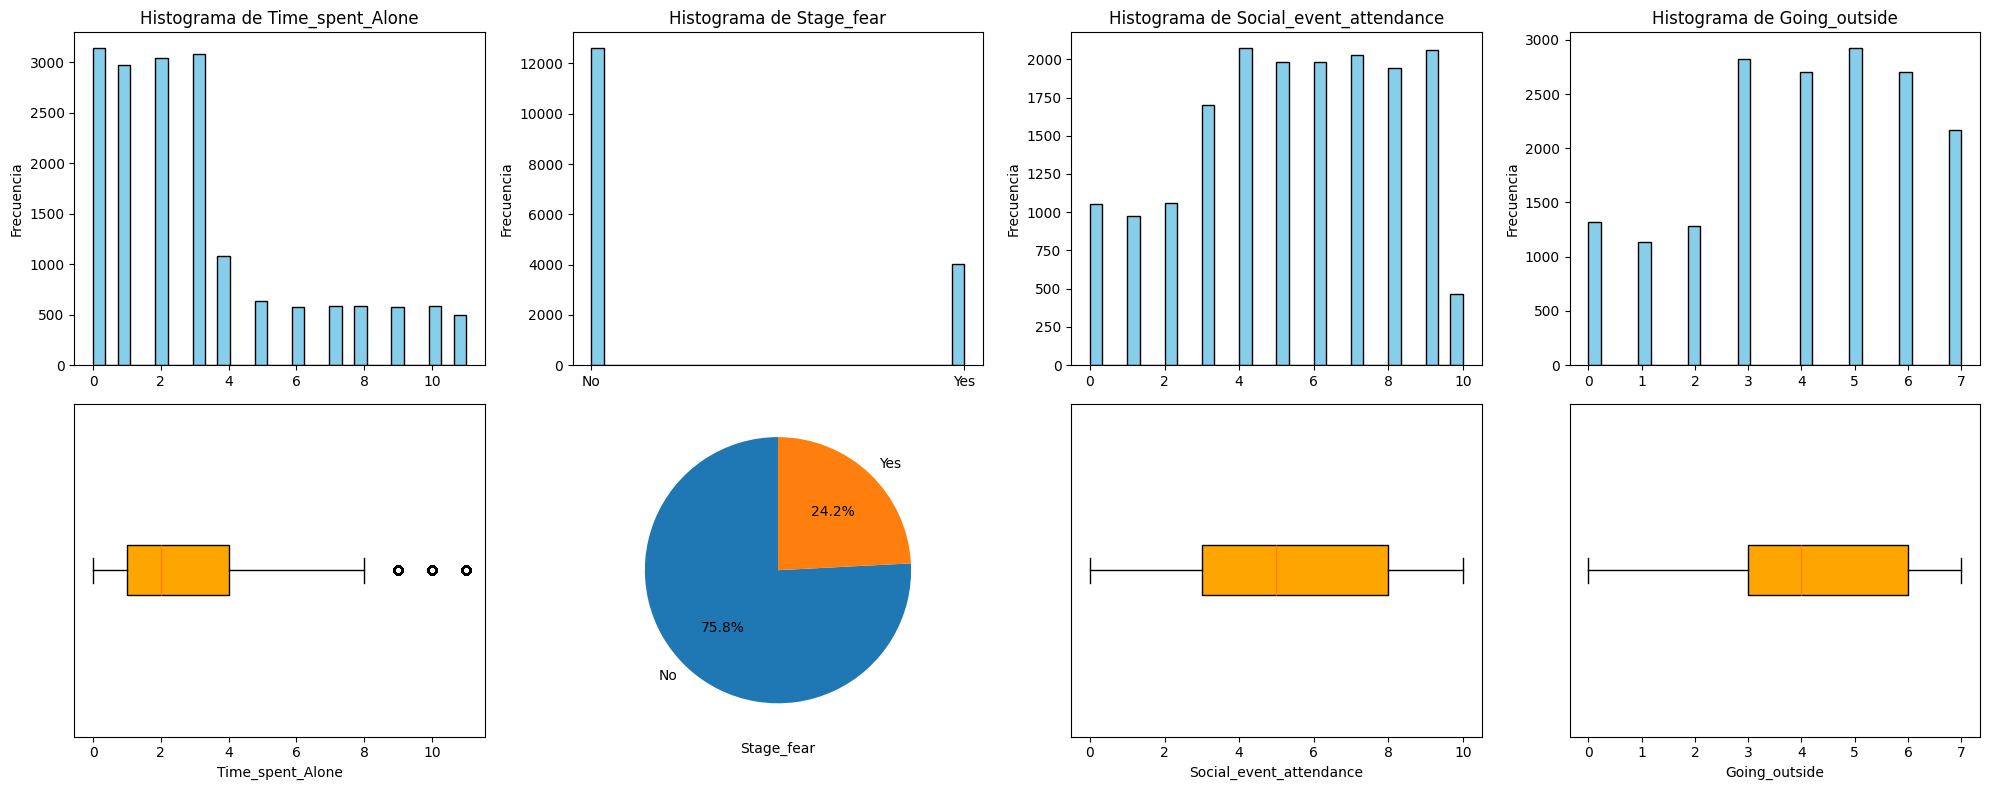

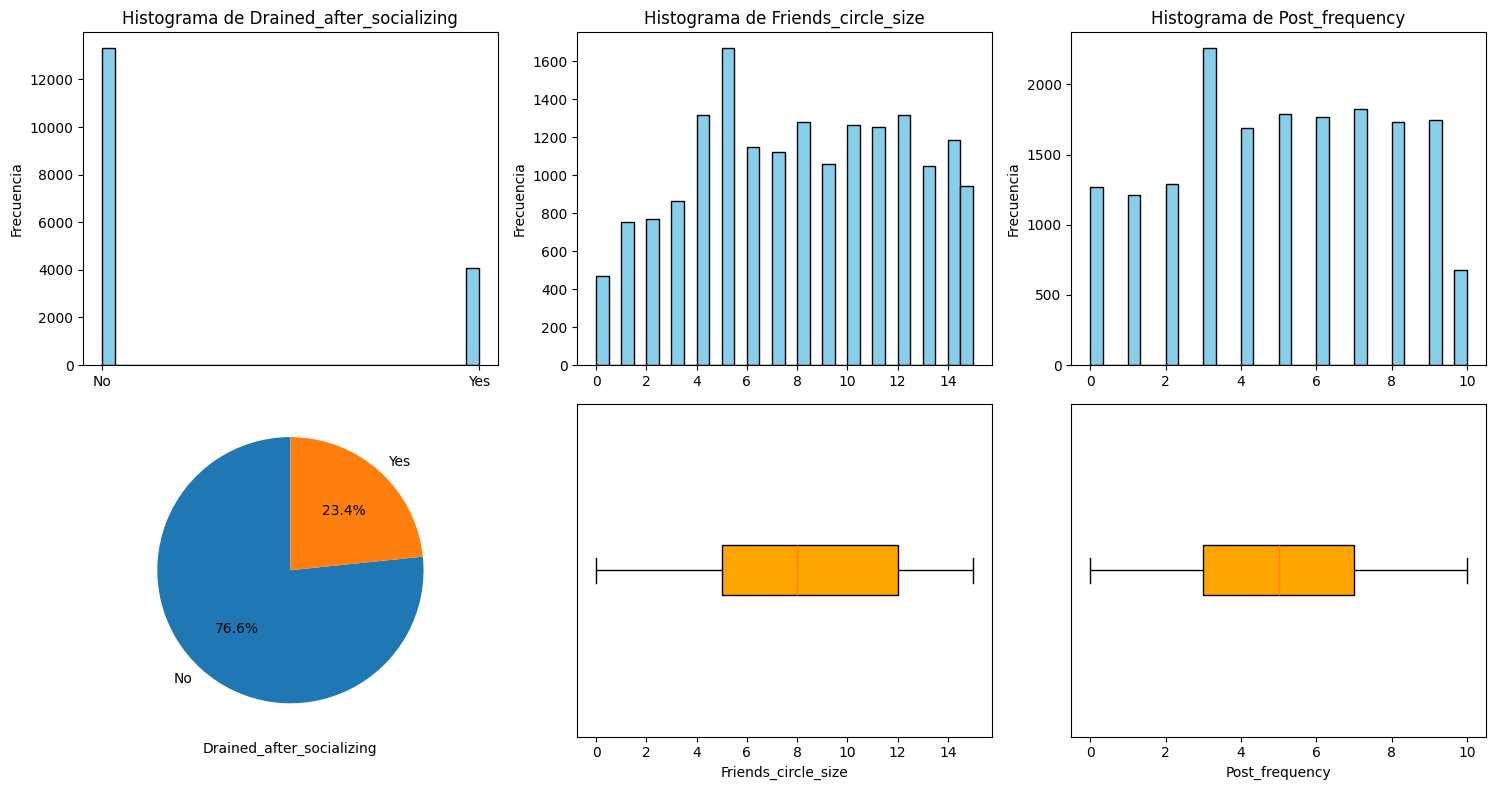

In [6]:
investigate_null_imputation(train)

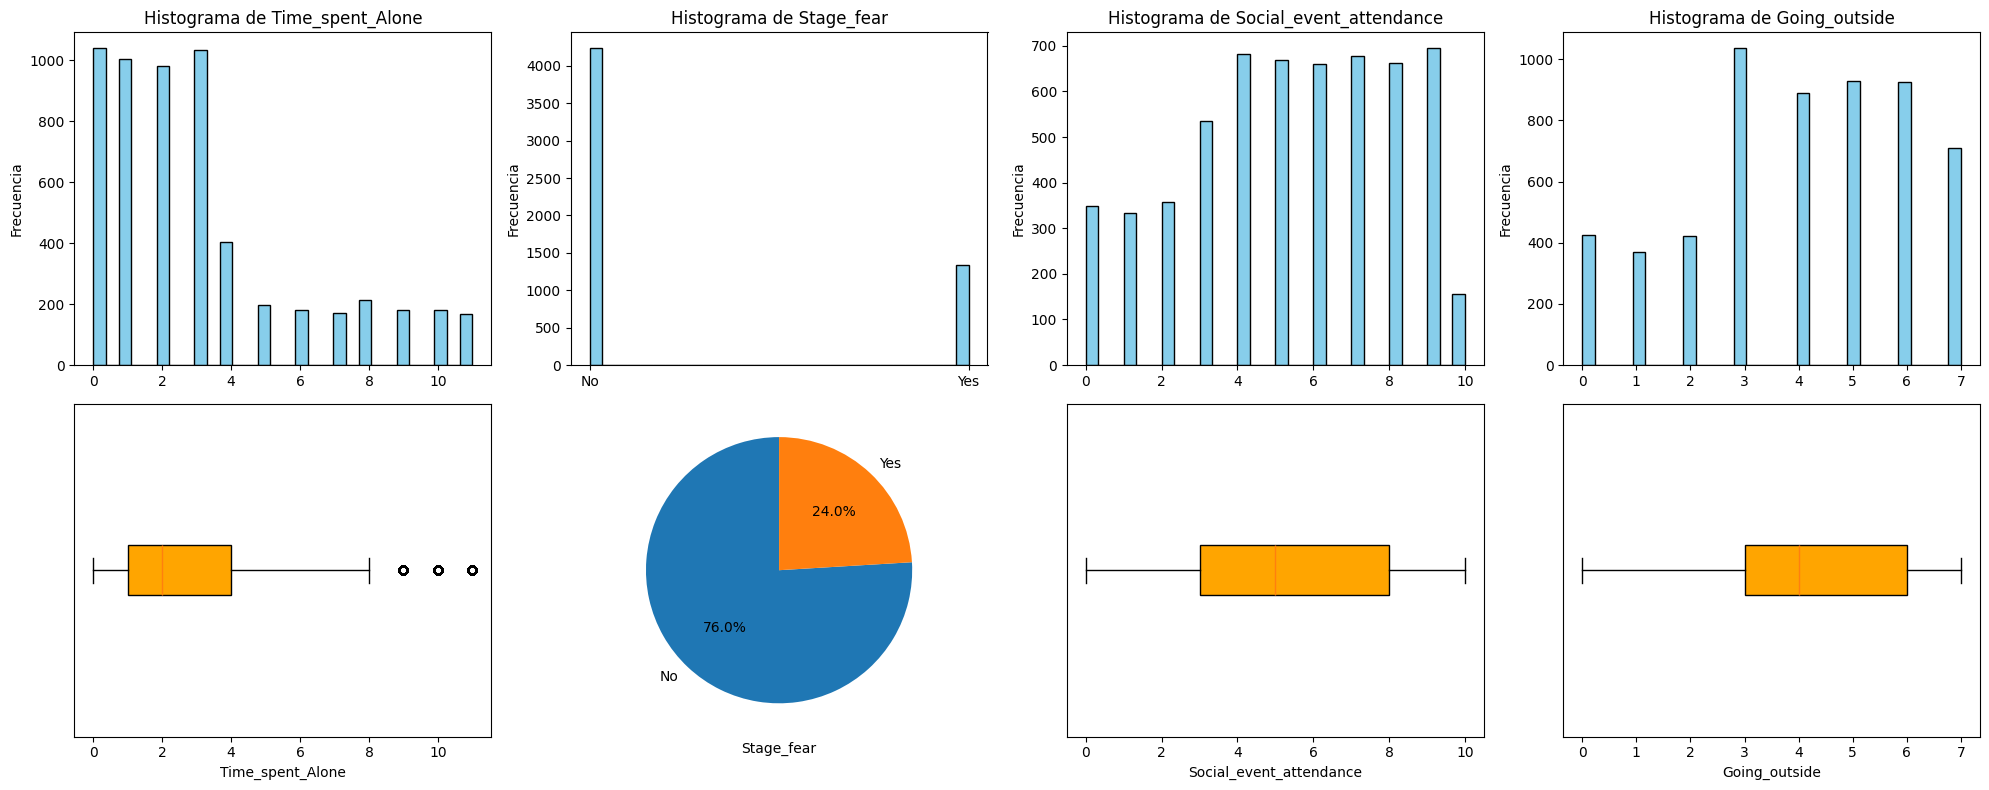

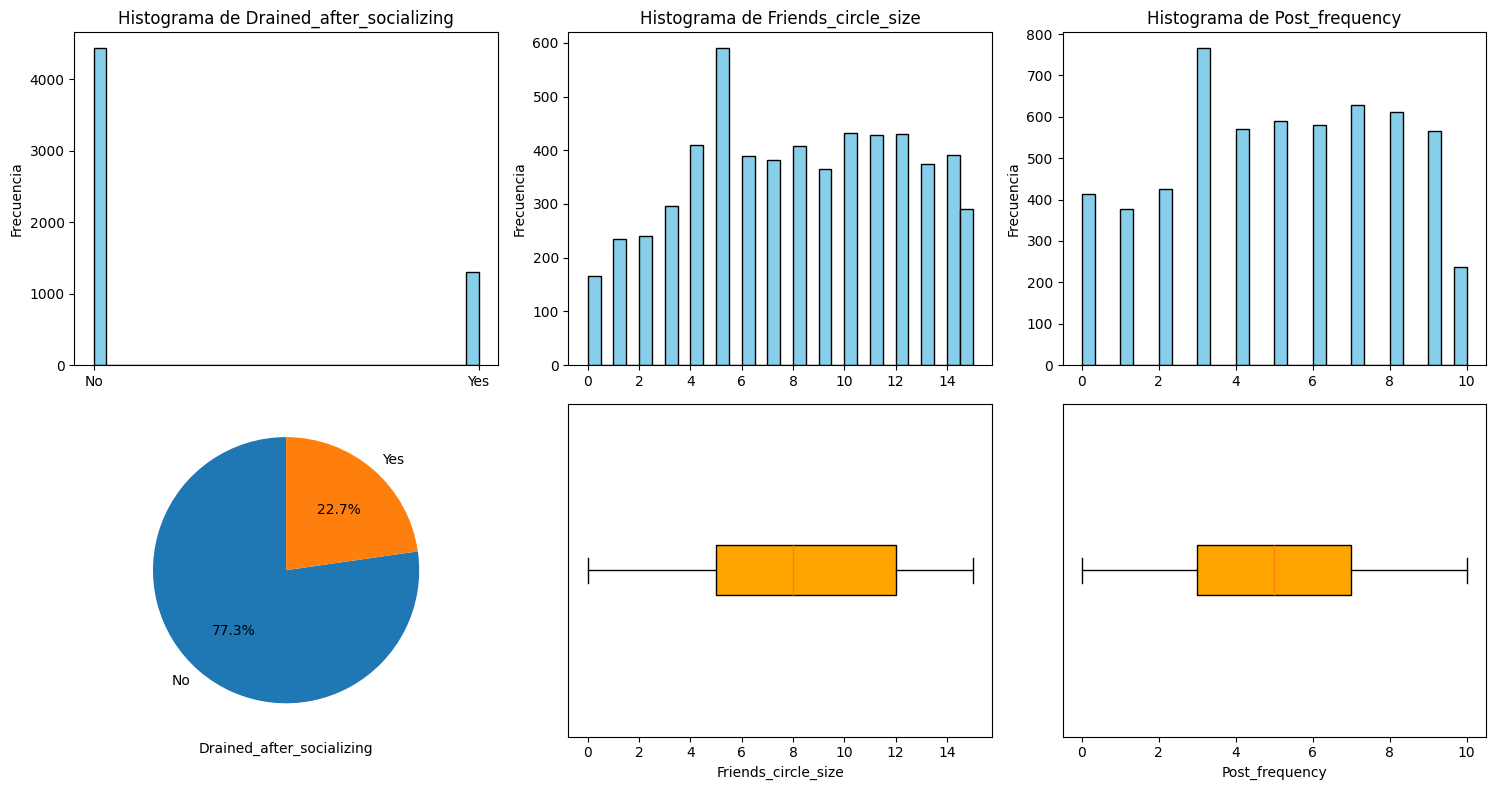

In [7]:
investigate_null_imputation(test)

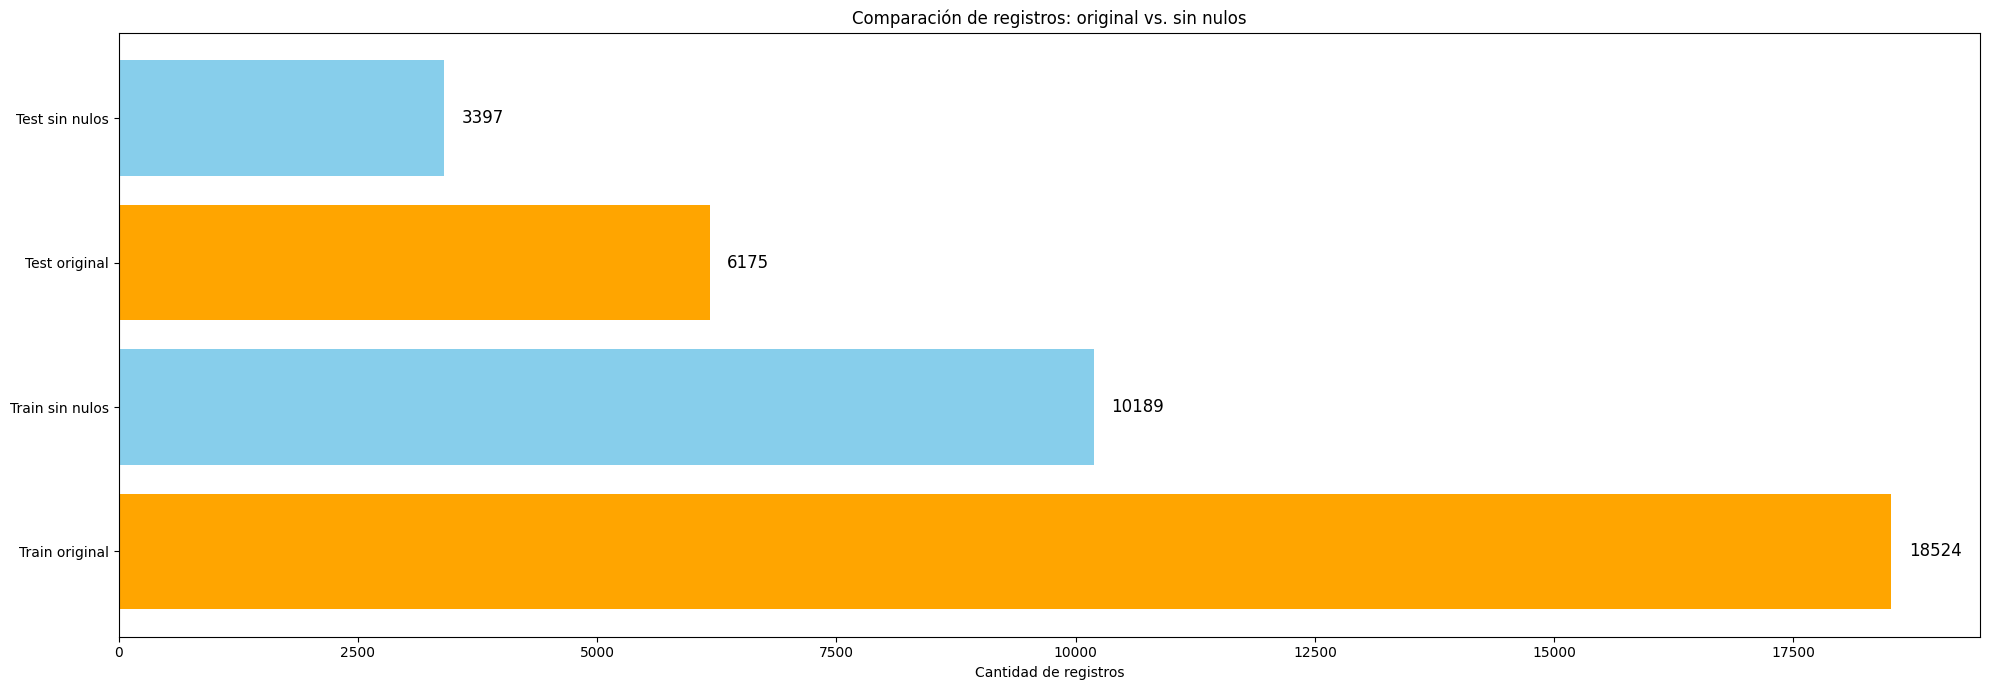

In [8]:
investigate_null_deletion(train, test, labels=('Train', 'Test'))

In [9]:
# Notes: Puedo hacer la imputacion, usando los valores de train y aplicarlos a test.

# Mi estrategia sera mean y moda.

# DATA WRANGLING:

## Mean Imputation (Numeric Columns)

In [10]:
from dm_santi.data_imputation import mean_imputation

In [11]:
column_nulls = train.columns[train.isnull().any()]


df_train_imputed, df_test_imputed = mean_imputation(train, column="all", df_test=test)

## Mode Imputation (Categorical Columns)

In [12]:
from dm_santi.data_imputation import mode_imputation

In [13]:
encoding_columns = "Stage_fear", "Drained_after_socializing"


df_train_imputed, df_test_imputed = mode_imputation(df_train_imputed, column="all", df_test=df_test_imputed)

## Encoding (Categorical Columns)

In [14]:
from dm_santi.data_encodings import yes_no_encoding

In [15]:
# Training
df_train_encoded = df_train_imputed.copy()
for column in encoding_columns:
    df_train_encoded = yes_no_encoding(df_train_encoded, column=column)
    df_train_encoded[column] = df_train_encoded[column]

# Test
df_test_encoded = df_test_imputed.copy()
for column in encoding_columns:
    df_test_encoded = yes_no_encoding(df_test_encoded, column=column)
    df_test_encoded[column] = df_test_encoded[column]

## Target Variable Encoding (Categorical Columns)

In [16]:
from dm_santi.data_encodings import binary_encoding

In [17]:
train_ready = binary_encoding(df_train_encoded, column="Personality", positive_value="extrovert", negative_value="introvert")
test_ready = binary_encoding(df_test_encoded, column="Personality", positive_value="extrovert", negative_value="introvert")

## Reviewing 2 data sets

In [18]:
train_ready

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.000000,0,6.0,4.0,0,15.0,5.000000,1
1,1,1.000000,0,7.0,3.0,0,10.0,8.000000,1
2,2,6.000000,1,1.0,0.0,0,3.0,0.000000,0
3,3,3.000000,0,7.0,3.0,0,11.0,5.000000,1
4,4,1.000000,0,4.0,4.0,0,13.0,4.982097,1
...,...,...,...,...,...,...,...,...,...
18519,18519,3.000000,0,7.0,3.0,0,9.0,7.000000,1
18520,18520,1.000000,0,6.0,7.0,0,6.0,5.000000,1
18521,18521,7.000000,1,1.0,1.0,1,1.0,4.982097,0
18522,18522,3.137764,1,1.0,0.0,1,5.0,2.000000,0


In [19]:
test_ready

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.000000,0,7.0,4.0,0,6.0,4.982097
1,18525,3.137764,1,0.0,0.0,1,5.0,1.000000
2,18526,3.000000,0,5.0,6.0,0,15.0,9.000000
3,18527,3.000000,0,4.0,4.0,0,5.0,6.000000
4,18528,9.000000,1,1.0,2.0,1,1.0,1.000000
...,...,...,...,...,...,...,...,...
6170,24694,3.000000,0,5.0,5.0,0,9.0,6.000000
6171,24695,8.000000,1,2.0,1.0,1,0.0,0.000000
6172,24696,2.000000,0,4.0,3.0,0,9.0,7.000000
6173,24697,3.000000,0,4.0,4.0,0,11.0,9.000000


# Machine Learning:

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Data preparation

In [21]:
# Remove ID, Personality
X_train = train_ready.drop(['id', 'Personality'], axis=1)
y_train = train_ready['Personality']

X_test = test_ready.drop(['id'], axis=1)
# y_test = test_ready['Personality'] # We want to predict this

X_train, X_validate, y_train, Y_validate = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

## Logistic Regression

### Training

In [22]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Evaluation (Train - Validation)

In [23]:
y_pred = logistic_model.predict(X_validate)

accuracy = accuracy_score(Y_validate, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(Y_validate, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_validate, y_pred))

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1206
           1       0.97      0.98      0.98      3425

    accuracy                           0.96      4631
   macro avg       0.96      0.95      0.95      4631
weighted avg       0.96      0.96      0.96      4631

Confusion Matrix:
[[1115   91]
 [  72 3353]]


In [24]:
### Inference 
y_test_pred = logistic_model.predict(X_test)



### Joining id and predictions
submission = pd.DataFrame({
    'id': test_ready['id'],
    'Personality': y_test_pred
})

# Convert 1 to extrovert and 0 to introvert
submission['Personality'] = submission['Personality'].map({1: 'Extrovert', 0: 'Introvert'})

submission.to_csv('submission_LR_1.csv', index=False)

## Supor Vector Machine

In [33]:
from sklearn import svm

suport_vector_model = svm.SVC(kernel='linear', random_state=42, coef0=1, cache_size=400, C=2)
suport_vector_model.fit(X_train, y_train)

SVC(C=2, cache_size=400, coef0=1, kernel='linear', random_state=42)

### Evaluation (Train - Validation)

In [34]:
y_pred = suport_vector_model.predict(X_validate)

accuracy = accuracy_score(Y_validate, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(Y_validate, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_validate, y_pred))

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1206
           1       0.97      0.98      0.98      3425

    accuracy                           0.96      4631
   macro avg       0.95      0.95      0.95      4631
weighted avg       0.96      0.96      0.96      4631

Confusion Matrix:
[[1109   97]
 [  74 3351]]


In [27]:
### Inference 
y_test_pred = suport_vector_model.predict(X_test)



### Joining id and predictions
submission = pd.DataFrame({
    'id': test_ready['id'],
    'Personality': y_test_pred
})

# Convert 1 to extrovert and 0 to introvert
submission['Personality'] = submission['Personality'].map({1: 'Extrovert', 0: 'Introvert'})

submission.to_csv('submission_SVM_1.csv', index=False)

## Decision Tree

In [49]:
from sklearn import tree

decision_tree_model = tree.DecisionTreeClassifier(random_state=42, max_depth=9, criterion="entropy")
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, random_state=42)

### Evaluation (Train - Validation)

In [50]:
y_pred = decision_tree_model.predict(X_validate)

accuracy = accuracy_score(Y_validate, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(Y_validate, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_validate, y_pred))

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1206
           1       0.97      0.98      0.97      3425

    accuracy                           0.96      4631
   macro avg       0.95      0.95      0.95      4631
weighted avg       0.96      0.96      0.96      4631

Confusion Matrix:
[[1107   99]
 [  77 3348]]


In [52]:
### Inference 
y_test_pred = decision_tree_model.predict(X_test)



### Joining id and predictions
submission = pd.DataFrame({
    'id': test_ready['id'],
    'Personality': y_test_pred
})

# Convert 1 to extrovert and 0 to introvert
submission['Personality'] = submission['Personality'].map({1: 'Extrovert', 0: 'Introvert'})

submission.to_csv('submission_DT_1.csv', index=False)

# HIDE

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Identifica las columnas numéricas y categóricas
numerical_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features = ['Stage_fear', 'Drained_after_socializing']

# Preprocesamiento para columnas numéricas: imputación + escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocesamiento para columnas categóricas: imputación + one-hot
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Une ambos pipelines en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# Pipeline final: preprocesador + clasificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Entrenamiento
X = train.drop('Personality', axis=1)
y = train['Personality'].str.lower().map({'extrovert': 1, 'introvert': 0})

model_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
# Evaluación
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the pipeline model: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy of the pipeline model: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1206
           1       0.97      0.97      0.97      3425

    accuracy                           0.96      4631
   macro avg       0.94      0.95      0.95      4631
weighted avg       0.96      0.96      0.96      4631

Confusion Matrix:
[[1117   89]
 [ 108 3317]]


# HIDE

In [ ]:

Santiago Reyes
EN BASE A ESTO USA SIKIT LEARN PARA ENTRENAR UN MODELO SIMPLE DE LOGISTIC REGRESSION PARA PREDECIR Personality


Gemini
¡Claro! Con gusto te ayudaré a crear un modelo de Regresión Logística con scikit-learn para predecir la variable "Personality".

Dado que los archivos de contexto no contienen un conjunto de datos, he creado un script completo que primero genera un archivo CSV de ejemplo (personality_data.csv) y luego lo utiliza para entrenar y evaluar el modelo. Este enfoque te permitirá ejecutar el código directamente y entender cada paso del proceso.

Explicación del Proceso
Generar y Cargar Datos: Creamos un DataFrame de pandas con datos ficticios que simulan puntuaciones de personalidad (apertura, extraversión, etc.) y una variable categórica (género). La columna objetivo es Personality, que en este ejemplo será 'Introvert' o 'Extrovert'.
Definir Features y Target: Separamos nuestro DataFrame en X (las variables predictoras o features) y y (la variable objetivo que queremos predecir, Personality).
Preprocesamiento: Es una buena práctica preprocesar los datos antes de entrenar el modelo.
Escalado de Variables Numéricas: Usamos StandardScaler para escalar las variables numéricas. Esto ayuda a que el modelo de regresión logística converja más rápido y funcione mejor, ya que pone todas las variables en la misma escala.
Codificación de Variables Categóricas: Usamos OneHotEncoder para convertir las variables categóricas (como 'gender') en un formato numérico que el modelo pueda entender.
Crear un Pipeline: Un Pipeline de scikit-learn es una herramienta excelente para encadenar múltiples pasos. Nuestro pipeline primero aplicará el preprocesamiento (escalado y codificación) y luego entrenará el clasificador de Regresión Logística. Esto evita la fuga de datos del conjunto de prueba al de entrenamiento y simplifica el código.
Dividir los Datos: Usamos train_test_split para dividir los datos en un conjunto de entrenamiento (para enseñar al modelo) y un conjunto de prueba (para evaluarlo con datos que no ha visto antes).
Entrenar el Modelo: Invocamos el método fit() en nuestro pipeline, pasándole los datos de entrenamiento (X_train, y_train).
Evaluar el Modelo: Hacemos predicciones sobre el conjunto de prueba (X_test) y comparamos los resultados con los valores reales (y_test). Calculamos la precisión (accuracy) y generamos un reporte de clasificación que nos da métricas más detalladas como la precisión, el recall y el f1-score para cada clase.
Código para Entrenar el Modelo
Aquí tienes el código completo. Puedes guardarlo como un archivo Python (por ejemplo, train_personality_model.py) y ejecutarlo.

python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

def train_personality_model():
    """
    Genera datos de ejemplo, entrena un modelo de Regresión Logística
    y evalúa su rendimiento.
    """
    # --- 1. Generar y guardar datos de ejemplo ---
    # En un caso real, cargarías tu propio CSV aquí.
    # ej: df = pd.read_csv('tu_archivo.csv')
    print("Generando un archivo de datos de ejemplo: 'personality_data.csv'...")
    data = {
        'openness': np.random.randint(1, 11, 200),
        'conscientiousness': np.random.randint(1, 11, 200),
        'extraversion': np.random.randint(1, 11, 200),
        'agreeableness': np.random.randint(1, 11, 200),
        'neuroticism': np.random.randint(1, 11, 200),
        'gender': np.random.choice(['Male', 'Female', 'Other'], 200),
        'Personality': ['Extrovert' if (e > 5 and o > 5) else 'Introvert' for e, o in zip(np.random.randint(1, 11, 200), np.random.randint(1, 11, 200))]
    }
    df = pd.DataFrame(data)
    df.to_csv('personality_data.csv', index=False)
    print("Datos guardados.")

    # --- 2. Cargar y preparar los datos ---
    df = pd.read_csv('personality_data.csv')

    # Definir las variables predictoras (X) y la variable objetivo (y)
    X = df.drop('Personality', axis=1)
    y = df['Personality']

    # Identificar columnas numéricas y categóricas
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(include='object').columns.tolist()

    print(f"\nVariables numéricas: {numerical_features}")
    print(f"Variables categóricas: {categorical_features}")

    # --- 3. Dividir los datos en conjuntos de entrenamiento y prueba ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    print(f"\nDatos de entrenamiento: {X_train.shape[0]} muestras")
    print(f"Datos de prueba: {X_test.shape[0]} muestras")

    # --- 4. Crear el pipeline de preprocesamiento y modelado ---
    # Crear un transformador para aplicar diferentes pasos a diferentes columnas
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Crear el pipeline final que une el preprocesador y el clasificador
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ])

    # --- 5. Entrenar el modelo ---
    print("\nEntrenando el modelo de Regresión Logística...")
    model_pipeline.fit(X_train, y_train)
    print("Entrenamiento completado.")

    # --- 6. Realizar predicciones y evaluar el modelo ---
    y_pred = model_pipeline.predict(X_test)

    # Calcular la precisión
    accuracy = accuracy_score(y_test, y_pred)
    
    # Generar el reporte de clasificación
    class_report = classification_report(y_test, y_pred)

    print("\n--- Resultados de la Evaluación ---")
    print(f"Precisión (Accuracy) del modelo: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(class_report)

    # --- 7. Ejemplo de predicción con un nuevo dato ---
    print("\n--- Ejemplo de Predicción Individual ---")
    new_data = pd.DataFrame([{
        'openness': 8,
        'conscientiousness': 7,
        'extraversion': 9,
        'agreeableness': 6,
        'neuroticism': 3,
        'gender': 'Female'
    }])
    prediction = model_pipeline.predict(new_data)
    prediction_proba = model_pipeline.predict_proba(new_data)
    
    print(f"Datos de entrada: \n{new_data.to_string(index=False)}")
    print(f"\nPredicción de Personalidad: {prediction[0]}")
    print(f"Probabilidades: {model_pipeline.classes_} -> {prediction_proba[0]}")


if __name__ == '__main__':
    train_personality_model()
Este script es un punto de partida robusto. Puedes reemplazar la sección de generación de datos con la carga de tu propio archivo CSV y adaptar los nombres de las columnas para que coincidan con tu conjunto de datos.

Context Sources (10)

Santiago Reyes
que me recomiendas ? hacer un pipeline para el procesamiento de datos ?


Gemini
¡Excelente pregunta! Es una de las decisiones más importantes para asegurar que tu proyecto de Machine Learning sea robusto, reproducible y fácil de mantener.

Mi recomendación es: Sí, definitivamente deberías usar un Pipeline para el procesamiento de datos.

En el código que te proporcioné antes, ya usé un Pipeline. Ahora te explico en detalle por qué es la mejor práctica y casi un estándar en la industria.

¿Qué es un Pipeline en Scikit-Learn?
Imagina un Pipeline (tubería) como una cadena de montaje para tus datos. Le dices qué pasos seguir y en qué orden, y él se encarga de ejecutar todo de forma automática. Cada paso es un "transformador" (como escalar o codificar variables) y el último paso es un "estimador" (el modelo que se va a entrenar).

¿Por Qué es Tan Recomendable Usar un Pipeline?
Previene la Fuga de Datos (Data Leakage): Este es el motivo más importante. La fuga de datos ocurre cuando la información de tu conjunto de prueba "se filtra" accidentalmente en tu conjunto de entrenamiento. Esto hace que tu modelo parezca mucho mejor en la evaluación de lo que realmente será con datos nuevos.

Escenario Incorrecto (Sin Pipeline): Si escalas todo el conjunto de datos antes de dividirlo en entrenamiento y prueba, el StandardScaler calcula la media y la desviación estándar usando todos los datos. Por lo tanto, tu conjunto de entrenamiento ya "sabe" algo sobre el conjunto de prueba, lo cual es hacer trampa.
Escenario Correcto (Con Pipeline): El Pipeline es inteligente. Cuando haces pipeline.fit(X_train, y_train), solo aprende los parámetros de escalado y codificación usando únicamente los datos de entrenamiento. Luego, cuando haces pipeline.predict(X_test), aplica esas mismas transformaciones (ya aprendidas) a los datos de prueba sin volver a aprender nada. Esto simula perfectamente cómo funcionaría el modelo en un entorno real.
Simplifica el Código y lo Hace Más Legible: Encapsulas todo el flujo de trabajo (preprocesamiento + modelo) en un único objeto. Esto hace que tu código sea mucho más limpio y fácil de seguir.

Sin Pipeline (más complejo y propenso a errores):

python
 Show full code block 
# 1. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, ...)

# 2. Crear y ajustar preprocesadores SOLO en train
scaler = StandardScaler()
encoder = OneHotEncoder()
X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
X_train_encoded_cat = encoder.fit_transform(X_train[cat_cols])
# ...luego hay que unir las columnas...

# 3. Aplicar transformaciones a test (¡solo transform, no fit!)
X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])
X_test_encoded_cat = encoder.transform(X_test[cat_cols])
# ...unir de nuevo...

# 4. Entrenar modelo
model = LogisticRegression()
model.fit(X_train_procesado, y_train)

# 5. Predecir
model.predict(X_test_procesado)
Con Pipeline (simple y robusto):

python
 Show full code block 
# 1. Dividir datos (¡antes de cualquier preprocesamiento!)
X_train, X_test, y_train, y_test = train_test_split(X, y, ...)

# 2. Definir el pipeline
preprocessor = ColumnTransformer(...)
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', LogisticRegression())])

# 3. Entrenar (fit se encarga de todo internamente)
model_pipeline.fit(X_train, y_train)

# 4. Predecir (predict se encarga de todo internamente)
y_pred = model_pipeline.predict(X_test)
Consistencia para Producción: Cuando quieras usar tu modelo para predecir sobre un dato nuevo que nunca has visto, no tienes que preocuparte por aplicar manualmente cada uno de los pasos de preprocesamiento en el orden correcto. Simplemente le pasas el dato nuevo al pipeline.predict() y él se encarga de todo.

Facilita la Búsqueda de Hiperparámetros (GridSearchCV): Puedes optimizar los parámetros del preprocesamiento y del modelo al mismo tiempo. Por ejemplo, podrías querer probar si es mejor usar StandardScaler o MinMaxScaler, o probar diferentes valores para el parámetro C de la Regresión Logística. Con un pipeline, esto es muy sencillo.

Conclusión
Usar un Pipeline no es solo una "buena idea", es una práctica fundamental para desarrollar modelos de Machine Learning de manera profesional. Te ahorra errores, simplifica tu código y asegura que tus resultados de evaluación sean fiables.

En resumen: ¡Sí, úsalo siempre que puedas!

Context Sources (9)

Santiago Reyes
from sklearn.pipeline import Pipeline from sklearn.compose import ColumnTransformer from sklearn.impute import SimpleImputer from sklearn.preprocessing import StandardScaler, OneHotEncoder from sklearn.linear_model import LogisticRegression

Identifica las columnas numéricas y categóricas
numerical_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency'] categorical_features = ['Stage_fear', 'Drained_after_socializing']

Preprocesamiento para columnas numéricas: imputación + escalado
numerical_pipeline = Pipeline(steps=[ ('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler()) ])

Preprocesamiento para columnas categóricas: imputación + one-hot
categorical_pipeline = Pipeline(steps=[ ('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore')) ])

Une ambos pipelines en un ColumnTransformer
preprocessor = ColumnTransformer( transformers=[ ('num', numerical_pipeline, numerical_features), ('cat', categorical_pipeline, categorical_features) ] )

Pipeline final: preprocesador + clasificador
model_pipeline = Pipeline(steps=[ ('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42, max_iter=1000)) ])

Entrenamiento
X = train.drop('Personality', axis=1) y = train['Personality'].str.lower().map({'extrovert': 1, 'introvert': 0})

model_pipeline.fit(X, y)

como lo meterias con un grid search ?


Gemini
¡Excelente iniciativa! Integrar GridSearchCV con tu Pipeline es la forma más robusta y profesional de encontrar los mejores hiperparámetros para tu modelo. Tu código actual ya está perfectamente estructurado para esto.

Viendo tus archivos, noto que en ml_santi/reg_ml.py ya tienes una función grid_search que encapsula GridSearchCV. ¡Eso es genial! El truco para usarla con tu model_pipeline es saber cómo nombrar los parámetros en el diccionario param_grid.

La Clave: Sintaxis step_name__parameter_name
Para acceder a los hiperparámetros de un paso dentro de un Pipeline, scikit-learn utiliza una sintaxis especial con un doble guion bajo (__).

La estructura es: <nombre_del_paso>__<nombre_del_parámetro>

Para el clasificador: Tu Pipeline final tiene un paso llamado 'classifier'. Para ajustar su parámetro C, usarías la clave 'classifier__C'.
Para el preprocesador: Es un poco más anidado. Tu pipeline tiene un paso 'preprocessor', que es un ColumnTransformer. Dentro de él, tienes un pipeline numérico llamado 'num'. Y dentro de ese, un imputador llamado 'imputer'. Para cambiar la estrategia de ese imputador, la clave sería: 'preprocessor__num__imputer__strategy'.
Código: Integrando GridSearchCV
Aquí te muestro cómo definir el param_grid y ejecutar la búsqueda de hiperparámetros basándote en tu código. He añadido la importación de GridSearchCV y la creación de datos de ejemplo para que el código sea ejecutable.

python
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# --- Creación de datos de ejemplo para que el script funcione ---
# En tu caso, ya tienes tu DataFrame 'train'
data = {
    'Time_spent_Alone': np.random.uniform(0, 10, 100),
    'Social_event_attendance': np.random.uniform(0, 5, 100),
    'Going_outside': np.random.uniform(0, 7, 100),
    'Friends_circle_size': np.random.randint(1, 20, 100),
    'Post_frequency': np.random.randint(0, 10, 100),
    'Stage_fear': np.random.choice(['Low', 'Medium', 'High', np.nan], 100),
    'Drained_after_socializing': np.random.choice(['Yes', 'No', np.nan], 100),
    'Personality': np.random.choice(['Extrovert', 'Introvert'], 100)
}
train = pd.DataFrame(data)
train.loc[5:10, 'Time_spent_Alone'] = np.nan # Introducir algunos NaNs
# ----------------------------------------------------------------

# --- Tu código de Pipeline (sin cambios) ---
# Identifica las columnas numéricas y categóricas
numerical_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features = ['Stage_fear', 'Drained_after_socializing']

# Preprocesamiento para columnas numéricas: imputación + escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocesamiento para columnas categóricas: imputación + one-hot
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Une ambos pipelines en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# Pipeline final: preprocesador + clasificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# --- Integración con GridSearchCV ---

# 1. Definir el espacio de búsqueda de hiperparámetros
#    Se usa la sintaxis 'paso__parametro' para acceder a los parámetros del pipeline.
param_grid = {
    # Probar diferentes estrategias de imputación para las variables numéricas
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    
    # Probar diferentes valores de regularización para la Regresión Logística
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    
    # Probar diferentes solvers (algunos son más rápidos para ciertos datos)
    'classifier__solver': ['liblinear', 'saga']
}

# 2. Preparar los datos
X = train.drop('Personality', axis=1)
y = train['Personality'].str.lower().map({'extrovert': 1, 'introvert': 0})

# 3. Configurar y ejecutar GridSearchCV
#    Esto es lo que tu función en reg_ml.py hace internamente.
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Usar todos los núcleos de CPU disponibles
)

print("Iniciando la búsqueda de hiperparámetros (Grid Search)...")
grid_search.fit(X, y)
print("Búsqueda completada.")

# 4. Mostrar los resultados
print("\n--- Resultados de GridSearchCV ---")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación de validación cruzada (accuracy): {grid_search.best_score_:.4f}")

# El mejor modelo ya está re-entrenado con todos los datos de entrenamiento
# y se puede acceder a él a través de 'best_estimator_'
best_model = grid_search.best_estimator_
print("\nMejor pipeline del modelo:")
print(best_model)

# Ahora puedes usar 'best_model' para hacer predicciones en tu conjunto de prueba.
# Ejemplo:
# predictions = best_model.predict(X_test)
Resumen de los Cambios:
param_grid: Creamos un diccionario donde las claves apuntan directamente a los parámetros que quieres optimizar dentro de tu model_pipeline. Incluí ejemplos tanto para un paso de preprocesamiento (imputer) como para el modelo final (classifier).
GridSearchCV: Instanciamos el objeto GridSearchCV, pasándole:
estimator=model_pipeline: Tu pipeline completo es el "modelo" que se va a evaluar.
param_grid: El diccionario que acabamos de definir.
cv=5: El número de divisiones para la validación cruzada.
scoring='accuracy': La métrica para decidir cuál es el "mejor" modelo.
n_jobs=-1: Un truco útil para acelerar la búsqueda usando todos los procesadores disponibles.
fit: Al llamar a grid_search.fit(X, y), GridSearchCV se encarga de todo: divide los datos, prueba cada combinación de parámetros, evalúa los resultados y, al final, re-entrena el mejor pipeline encontrado usando todos los datos de entrenamiento.
Este enfoque es extremadamente potente porque optimiza el flujo de trabajo completo (imputación, escalado y clasificación) de una sola vez, respetando las divisiones de datos y evitando la fuga de información.

Context Sources (10)
Prompts to try
1 machine learning.ipynb:1-41
Add to Chat Context
1 context item
Context items

Current file
1 machine learning.ipynb#X32sZmlsZQ==


SyntaxError: invalid syntax (1296361766.py, line 1)